# First steps com dados BTC
* Different options to drop
* Fill nan
* Imputer
* Correlacao entre precos e volume


In [19]:
import pyspark

In [20]:
# Import PySpark and create a SparkSession
from pyspark.sql import SparkSession
# https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrameReader.html#pyspark.sql.DataFrameReader
spark = SparkSession.builder.appName("ImportData").getOrCreate()

In [21]:
spark

# Ler o ficheiro BTC (Parquet)


In [22]:
# Ler dados BTC em formato Parquet (dados reais da Binance)
# https://spark.apache.org/docs/latest/sql-data-sources-parquet.html
df_btc = spark.read.parquet("./../data/btc_04h_usdt_binance.parquet")

In [23]:
df_btc.show(10, truncate=30)


+-------------------+-------+-------+-------+-------+----------+-----------------------+----------------+------+--------------+---------------+------+-------+-------------------+-------------------+----------+---------+---------------------+-------------+-------------------+-----------+----------+------------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+--------------+------------------+------------------+----------------+--------------------+---------------+---------------+--------------+--------------+--------------+--------------+--------------+-----------------+-------------+----------+-----------------+---------------+--------------+--------------+--------------+--------------+--------------------+--------------------+---------------------+----------+----------------+---------+---------+-------------+--------------+-------------------+-------------------+----------------+------------------+---------+---------+----

In [24]:
type(df_btc)


pyspark.sql.classic.dataframe.DataFrame

In [25]:
df_btc.describe().show(truncate=10)


26/05/08 20:22:53 WARN DAGScheduler: Broadcasting large task binary with size 1347.4 KiB


+-------+----------+----------+----------+----------+----------+----------+----------+--------------+---------------+------+-------+----------+----------+----------+----------+----------+-------------+----------+-----------+----------+----------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+----------+-----------------+---------------+--------------+--------------+--------------+--------------+--------------------+--------------------+---------------------+----------+----------------+----------+----------+-------------+--------------+-------------------+-------------------+----------------+----------------+----------+----------+-------------+-------------+----------+-----------------------+-----------------------+-----

In [26]:
df_btc.columns


['open_time',
 'open',
 'high',
 'low',
 'close',
 'volume',
 'close_time',
 'quote_vol',
 'trades',
 'taker_buy_base',
 'taker_buy_quote',
 'ignore',
 'symbol',
 'volume_adi',
 'volume_obv',
 'volume_cmf',
 'volume_fi',
 'volume_em',
 'volume_sma_em',
 'volume_vpt',
 'volume_vwap',
 'volume_mfi',
 'volume_nvi',
 'volatility_bbm',
 'volatility_bbh',
 'volatility_bbl',
 'volatility_bbw',
 'volatility_bbp',
 'volatility_bbhi',
 'volatility_bbli',
 'volatility_kcc',
 'volatility_kch',
 'volatility_kcl',
 'volatility_kcw',
 'volatility_kcp',
 'volatility_kchi',
 'volatility_kcli',
 'volatility_dcl',
 'volatility_dch',
 'volatility_dcm',
 'volatility_dcw',
 'volatility_dcp',
 'volatility_atr',
 'volatility_ui',
 'trend_macd',
 'trend_macd_signal',
 'trend_macd_diff',
 'trend_sma_fast',
 'trend_sma_slow',
 'trend_ema_fast',
 'trend_ema_slow',
 'trend_vortex_ind_pos',
 'trend_vortex_ind_neg',
 'trend_vortex_ind_diff',
 'trend_trix',
 'trend_mass_index',
 'trend_dpo',
 'trend_kst',
 'trend_kst

In [27]:
len(df_btc.columns)

112

In [28]:
features = ['open', 'high', 'low', 'close', 'volume']

In [29]:
df_btc[features].show()

+-------+-------+-------+-------+----------+
|   open|   high|    low|  close|    volume|
+-------+-------+-------+-------+----------+
|4261.48|4349.99|4261.32|4349.99| 82.088865|
|4333.32|4485.39|4333.32| 4427.3| 63.619882|
|4436.06|4485.39|4333.42|4352.34|174.562001|
|4352.33|4354.84|4200.74|4325.23|225.109716|
|4307.56|4369.69|4258.56|4285.08|249.769913|
|4285.08|4340.62|4134.61|4292.39|276.193043|
|4292.39|4340.62|4234.43|4300.25|248.389029|
| 4285.0|4371.52|4259.85|4340.31|196.140129|
|4320.52|4340.31| 4193.7|4236.89|175.969384|
|4234.54|4297.75| 4015.7|4136.28| 193.64697|
| 4135.0|4136.48|3938.77|4108.37|109.549709|
|4108.37|4184.69|4084.28|4138.55|108.510448|
| 4138.5| 4156.0|3933.21|4033.47|112.752079|
|4033.47|4082.25| 3850.0| 3957.6| 77.256042|
|3945.12| 4100.0|3928.89|3972.05| 47.515578|
|4036.19|4103.92| 3953.4|4076.12| 25.925056|
|4088.71|4149.99|4051.47|4139.98|   9.35056|
|4120.98|4139.98| 4044.0|4094.62|  6.611283|
|4094.62|4156.56|4081.19|4155.87|  28.60391|
|4155.87|4

In [30]:
df_btc.select(features).show(10, truncate=30)

+-------+-------+-------+-------+----------+
|   open|   high|    low|  close|    volume|
+-------+-------+-------+-------+----------+
|4261.48|4349.99|4261.32|4349.99| 82.088865|
|4333.32|4485.39|4333.32| 4427.3| 63.619882|
|4436.06|4485.39|4333.42|4352.34|174.562001|
|4352.33|4354.84|4200.74|4325.23|225.109716|
|4307.56|4369.69|4258.56|4285.08|249.769913|
|4285.08|4340.62|4134.61|4292.39|276.193043|
|4292.39|4340.62|4234.43|4300.25|248.389029|
| 4285.0|4371.52|4259.85|4340.31|196.140129|
|4320.52|4340.31| 4193.7|4236.89|175.969384|
|4234.54|4297.75| 4015.7|4136.28| 193.64697|
+-------+-------+-------+-------+----------+
only showing top 10 rows


# Drop e tratamento de nulls
* Vamos utilizar isnull
* Aplicar ao dataset BTC


In [31]:
from pyspark.sql.functions import col,isnan,isnull,when

# Verificar nulls na coluna volume
df_btc.select("open_time", "close", "volume").where(isnull("volume")).show()

+---------+-----+------+
|open_time|close|volume|
+---------+-----+------+
+---------+-----+------+



In [32]:
df_btc.na.fill(0).show(truncate=20)

+-------------------+-------+-------+-------+-------+----------+--------------------+----------------+------+--------------+---------------+------+-------+-------------------+-------------------+-------------------+-------------------+--------------------+--------------------+--------------------+-----------------+------------------+------------------+--------------+-----------------+------------------+------------------+------------------+---------------+---------------+------------------+------------------+------------------+------------------+--------------------+---------------+---------------+--------------+--------------+--------------+----------------+-----------------+------------------+-----------------+----------+-----------------+---------------+------------------+--------------+-----------------+--------------+--------------------+--------------------+---------------------+----------+----------------+-----------------+------------------+------------------+------------------

In [33]:
df_btc.na.drop().show(truncate=20)

+---------+----+----+---+-----+------+----------+---------+------+--------------+---------------+------+------+----------+----------+----------+---------+---------+-------------+----------+-----------+----------+----------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+----------+-----------------+---------------+--------------+--------------+--------------+--------------+--------------------+--------------------+---------------------+----------+----------------+---------+---------+-------------+--------------+-------------------+-------------------+----------------+----------------+---------+---------+-------------+-------------+---------+-----------------------+-----------------------+--------------+----------------+-

In [34]:
# drop any row with null in volume
df_btc.na.drop(how="any", subset=['volume']).show(truncate=5)

+---------+-----+-----+-----+-----+------+----------+---------+------+--------------+---------------+------+------+----------+----------+----------+---------+---------+-------------+----------+-----------+----------+----------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+----------+-----------------+---------------+--------------+--------------+--------------+--------------+--------------------+--------------------+---------------------+----------+----------------+---------+---------+-------------+--------------+-------------------+-------------------+----------------+----------------+---------+---------+-------------+-------------+---------+-----------------------+-----------------------+--------------+--------------

In [35]:
# fill volume nulls with 0
df_btc.na.fill(0, ["volume"]).show(truncate=5)


+---------+-----+-----+-----+-----+------+----------+---------+------+--------------+---------------+------+------+----------+----------+----------+---------+---------+-------------+----------+-----------+----------+----------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+----------+-----------------+---------------+--------------+--------------+--------------+--------------+--------------------+--------------------+---------------------+----------+----------------+---------+---------+-------------+--------------+-------------------+-------------------+----------------+----------------+---------+---------+-------------+-------------+---------+-----------------------+-----------------------+--------------+--------------

# Imputer
* Preenche valores em falta com a mediana


In [36]:
from pyspark.ml.feature import Imputer

imputer = Imputer(
    inputCols=['volume'], 
    outputCols=["{}_imputed".format(c) for c in ['volume']]
    ).setStrategy("median")


In [37]:
imputer.fit(df_btc).transform(df_btc).show(truncate=5)


+---------+-----+-----+-----+-----+------+----------+---------+------+--------------+---------------+------+------+----------+----------+----------+---------+---------+-------------+----------+-----------+----------+----------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+----------+-----------------+---------------+--------------+--------------+--------------+--------------+--------------------+--------------------+---------------------+----------+----------------+---------+---------+-------------+--------------+-------------------+-------------------+----------------+----------------+---------+---------+-------------+-------------+---------+-----------------------+-----------------------+--------------+--------------

# Matriz de correlacao BTC
* Analisar relacoes entre OHLCV
* Converter para vector com 1 dimensao
* Visualizar com heatmap


In [38]:
# Ler dados BTC em formato Parquet (dados reais da Binance)
# https://spark.apache.org/docs/latest/sql-data-sources-parquet.html
df_btc = spark.read.parquet('data/btc_04h_usdt_binance.parquet')

26/05/08 20:22:57 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: data/btc_04h_usdt_binance.parquet.
java.io.FileNotFoundException: File data/btc_04h_usdt_binance.parquet does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:980)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1301)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:970)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamSink$.hasMetadata(FileStreamSink.scala:58)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:384)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.scala:143)
	at org.apache.spark.s

AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/home/sobreiro/git/teaching/big_data/notebooks/data/btc_04h_usdt_binance.parquet. SQLSTATE: 42K03

In [ ]:
from pyspark.ml.stat import Correlation
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler
import pyspark.sql.functions as F

In [ ]:
df_btc[features].show(5)


+---+---+---------+-------+-------+-------+--------+-----+---------+----+------+-------+
|age|sex|dayswfreq|tbilled|maccess|freeuse|nentries|cfreq|nrenewals|cref|months|dropout|
+---+---+---------+-------+-------+-------+--------+-----+---------+----+------+-------+
| 23|  1|        7|   37.6|   1.35|      0|       6|    7|        0|   0|     1|      1|
| 34|  1|      328|  205.6|   0.54|      0|      39|    7|        2|   0|    19|      0|
| 24|  0|        3|  140.0|    0.8|      0|      28|    7|        0|   0|     8|      1|
| 20|  1|       41|   71.6|    1.0|      0|      13|    7|        0|   0|     3|      1|
| 21|  1|       18|  113.2|   0.08|      0|       7|    7|        3|   0|    24|      1|
+---+---+---------+-------+-------+-------+--------+-----+---------+----+------+-------+
only showing top 5 rows



## Verificar valores nulos
```python
df_btc.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in features]).show()
```
* Conta quantos nulls existem em cada coluna numerica


In [ ]:
import pyspark.sql.functions as F

# Verificar nulls em todas as features numericas
df_btc.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in features]).show()


+---+---+---------+-------+-------+-------+--------+-----+---------+----+------+-------+
|age|sex|dayswfreq|tbilled|maccess|freeuse|nentries|cfreq|nrenewals|cref|months|dropout|
+---+---+---------+-------+-------+-------+--------+-----+---------+----+------+-------+
|  0|  0|        0|      0|      0|      5|       0|    6|        0|   0|     0|      0|
+---+---+---------+-------+-------+-------+--------+-----+---------+----+------+-------+



In [ ]:
df_btc.filter(df_btc['volume'].isNull()).show(5)


+--------------------+---+---+---------+-------+-------+-------+--------+-----+---------+----+--------------------+------+-------+
|                  Id|age|sex|dayswfreq|tbilled|maccess|freeuse|nentries|cfreq|nrenewals|cref|           startDate|months|dropout|
+--------------------+---+---+---------+-------+-------+-------+--------+-----+---------+----+--------------------+------+-------+
|0069B925-0586-4E7...| 44|  0|       45|  314.7|   0.93|   NULL|      52|    7|        2|   0|2015-04-17 08:06:...|    15|      1|
|0083CE4F-47A8-45B...| 20|  0|       56|  201.7|   0.31|   NULL|      27|    7|        3|   0|2015-10-02 12:06:...|    22|      1|
|0088A9D2-5494-485...| 21|  0|        4|   73.6|   2.26|   NULL|      21|    7|        0|   0|2017-02-28 12:44:...|     3|      1|
|009BD52A-653D-4FE...| 21|  1|       92|   37.6|   0.11|   NULL|       1|    7|        1|   0|2015-06-15 10:07:...|     3|      1|
|00C476BE-79D1-45F...| 26|  0|       39|  188.6|   1.06|   NULL|      28|    7|    

In [ ]:
df_btc.filter(df_btc['close'].isNull()).show(10)


+--------------------+---+---+---------+-------+-------+-------+--------+-----+---------+----+--------------------+------+-------+
|                  Id|age|sex|dayswfreq|tbilled|maccess|freeuse|nentries|cfreq|nrenewals|cref|           startDate|months|dropout|
+--------------------+---+---+---------+-------+-------+-------+--------+-----+---------+----+--------------------+------+-------+
|4CA4608D-9366-46C...| 26|  0|       22|   58.6|    0.7|      0|       3| NULL|        0|   0|2017-10-02 12:56:...|     1|      0|
|649D78E8-4C98-439...| 26|  0|        6|  126.1|   0.03|      0|       3| NULL|        2|   0|2015-10-09 09:52:...|    25|      0|
|6ABEE4C8-951A-4FE...| 21|  0|        8|   58.6|   1.63|      0|       7| NULL|        0|   0|2017-10-02 15:05:...|     1|      0|
|A7438DA1-1801-4E7...| 18|  0|        5|   58.6|   3.25|      0|      13| NULL|        0|   0|2017-10-04 18:55:...|     1|      0|
|AEEDCE35-83DC-4CC...| 20|  0|        4|   58.6|   3.03|      0|      13| NULL|    

In [ ]:
# Remover nulls em volume e close
df_btc = df_btc.dropna(subset=['volume', 'close'])


In [ ]:
import pyspark.sql.functions as F

# Verificar nulls em todas as features numericas
df_btc.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in features]).show()


+---+---+---------+-------+-------+-------+--------+-----+---------+----+------+-------+
|age|sex|dayswfreq|tbilled|maccess|freeuse|nentries|cfreq|nrenewals|cref|months|dropout|
+---+---+---------+-------+-------+-------+--------+-----+---------+----+------+-------+
|  0|  0|        0|      0|      0|      0|       0|    0|        0|   0|     0|      0|
+---+---+---------+-------+-------+-------+--------+-----+---------+----+------+-------+



In [ ]:
df_btc.show(5)


+--------------------+---+---+---------+-------+-------+-------+--------+-----+---------+----+--------------------+------+-------+
|                  Id|age|sex|dayswfreq|tbilled|maccess|freeuse|nentries|cfreq|nrenewals|cref|           startDate|months|dropout|
+--------------------+---+---+---------+-------+-------+-------+--------+-----+---------+----+--------------------+------+-------+
|00130FE8-5D34-4C6...| 23|  1|        7|   37.6|   1.35|      0|       6|    7|        0|   0|2017-05-02 09:43:...|     1|      1|
|0016D0DD-E713-4ED...| 34|  1|      328|  205.6|   0.54|      0|      39|    7|        2|   0|2016-04-20 18:33:...|    19|      0|
|001A70CA-0985-42D...| 24|  0|        3|  140.0|    0.8|      0|      28|    7|        0|   0|2015-12-01 19:47:...|     8|      1|
|001B9AC2-7711-438...| 20|  1|       41|   71.6|    1.0|      0|      13|    7|        0|   0|2015-10-06 16:33:...|     3|      1|
|001D927E-ACD2-4B3...| 21|  1|       18|  113.2|   0.08|      0|       7|    7|    

In [ ]:
features

['age',
 'sex',
 'dayswfreq',
 'tbilled',
 'maccess',
 'freeuse',
 'nentries',
 'cfreq',
 'nrenewals',
 'cref',
 'months',
 'dropout']

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

assembler = VectorAssembler(inputCols=features, outputCol="features")
df_assembled = assembler.transform(df_btc)
df_assembled.select("open_time", "close", "features").show()

In [ ]:
matrix = Correlation.corr(df_assembled, "features")
result = matrix.collect()[0]["pearson(features)"].values
result


array([ 1.        , -0.05261184, -0.06114127,  0.26556974,  0.07153221,
        0.02573219,  0.09373279, -0.25086728,  0.09222838,  0.0539945 ,
        0.08846267, -0.23279579, -0.05261184,  1.        , -0.04695518,
        0.03849536,  0.10444157,  0.07207284,  0.09380605,  0.10280766,
        0.01727373, -0.0063087 ,  0.04409213, -0.00895751, -0.06114127,
       -0.04695518,  1.        , -0.13416639, -0.41439499,  0.0100679 ,
       -0.18758926, -0.01153372,  0.23681088, -0.01244277,  0.17923565,
        0.18040598,  0.26556974,  0.03849536, -0.13416639,  1.        ,
        0.1792693 ,  0.12820067,  0.73227319, -0.13314389,  0.54869229,
        0.11083614,  0.68522171, -0.35504036,  0.07153221,  0.10444157,
       -0.41439499,  0.1792693 ,  1.        , -0.01988687,  0.46971485,
        0.07759188, -0.15047663, -0.01284269, -0.11103708, -0.25033027,
        0.02573219,  0.07207284,  0.0100679 ,  0.12820067, -0.01988687,
        1.        ,  0.11909698,  0.03229684,  0.15129051,  0.04

In [ ]:
matrix.collect()[0]["pearson(features)"].values


array([ 1.        , -0.05261184, -0.06114127,  0.26556974,  0.07153221,
        0.02573219,  0.09373279, -0.25086728,  0.09222838,  0.0539945 ,
        0.08846267, -0.23279579, -0.05261184,  1.        , -0.04695518,
        0.03849536,  0.10444157,  0.07207284,  0.09380605,  0.10280766,
        0.01727373, -0.0063087 ,  0.04409213, -0.00895751, -0.06114127,
       -0.04695518,  1.        , -0.13416639, -0.41439499,  0.0100679 ,
       -0.18758926, -0.01153372,  0.23681088, -0.01244277,  0.17923565,
        0.18040598,  0.26556974,  0.03849536, -0.13416639,  1.        ,
        0.1792693 ,  0.12820067,  0.73227319, -0.13314389,  0.54869229,
        0.11083614,  0.68522171, -0.35504036,  0.07153221,  0.10444157,
       -0.41439499,  0.1792693 ,  1.        , -0.01988687,  0.46971485,
        0.07759188, -0.15047663, -0.01284269, -0.11103708, -0.25033027,
        0.02573219,  0.07207284,  0.0100679 ,  0.12820067, -0.01988687,
        1.        ,  0.11909698,  0.03229684,  0.15129051,  0.04

In [ ]:
len(features)


12

In [ ]:
import numpy as np

correlation_values = matrix.collect()[0]["pearson(features)"].values
num_features = len(features)
correlation_matrix = np.array(correlation_values).reshape(num_features, num_features)


In [ ]:
correlation_matrix


array([[ 1.        , -0.05261184, -0.06114127,  0.26556974,  0.07153221,
         0.02573219,  0.09373279, -0.25086728,  0.09222838,  0.0539945 ,
         0.08846267, -0.23279579],
       [-0.05261184,  1.        , -0.04695518,  0.03849536,  0.10444157,
         0.07207284,  0.09380605,  0.10280766,  0.01727373, -0.0063087 ,
         0.04409213, -0.00895751],
       [-0.06114127, -0.04695518,  1.        , -0.13416639, -0.41439499,
         0.0100679 , -0.18758926, -0.01153372,  0.23681088, -0.01244277,
         0.17923565,  0.18040598],
       [ 0.26556974,  0.03849536, -0.13416639,  1.        ,  0.1792693 ,
         0.12820067,  0.73227319, -0.13314389,  0.54869229,  0.11083614,
         0.68522171, -0.35504036],
       [ 0.07153221,  0.10444157, -0.41439499,  0.1792693 ,  1.        ,
        -0.01988687,  0.46971485,  0.07759188, -0.15047663, -0.01284269,
        -0.11103708, -0.25033027],
       [ 0.02573219,  0.07207284,  0.0100679 ,  0.12820067, -0.01988687,
         1.        ,  

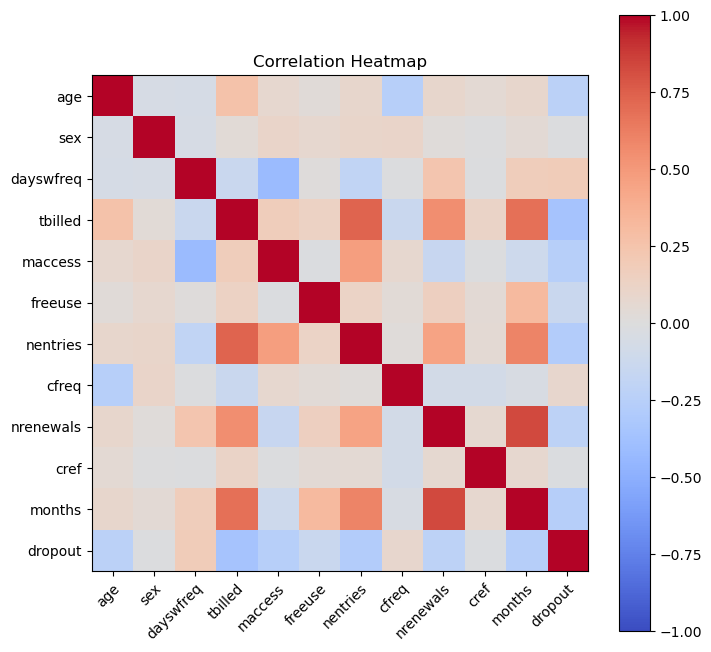

In [ ]:
len(features)


In [ ]:
# Correlacao direta entre close e volume
df_btc.corr('close', 'volume')


0.8323731760207659

In [ ]:
# Stop the SparkSession
spark.stop()